In [1]:
run_gridsearch = False
USE_BAYESIAN = False
N_BAYES_TRIALS = 36

skip_best_model_validation = True
skip_best_model_test = False
verbose = True
GPU_SETTING = -1
NUM_ENSEMBLES = 1
NUM_ENSEMBLES_FINAL = 1  # ensemble count for final training (validation/test)
HYPERPARAM_ENSEMBLE = False # If HYPERPARAM_ENSEMBLE is True, it overrides BOOTSTRAP_MODEL
BOOTSTRAP_MODELS = False 

BASIN = "guerneville"
RES_1H = "mts_hourly"
RES_1D = "mts_daily"

RUN_LABEL = "PEAK_NSE_PENALTY_V2"
MODE = "mts"
READ_STAMP = "20260414T002640Z"
# READ_STAMP = ""

# use_cv_for_selection = True
use_cv_for_selection = True
CV_INTERVAL_LENGTH = 2
CV_VALIDATION_LENGTH = 1
CV_INTERVAL_MONTH = 'October'

GRID_RANK_METRICS = ["NSE_1D", "NSE_1H"]
GRID_RANK_WEIGHTS = [0.3, 0.7]


In [2]:
hyperparam_space = {
    "hidden_size": [64, 128, 256],
    "output_dropout": [0.4],
    "seq_length_1D": [90],
    "seq_length_1H": [168, 336],
    "num_layers": [1],
    "epochs": [300],  
    "batch_size": [64],
    # "schedule_pairs": [  # plateau ES handles LR - no manual schedule needed
    #     ((0.5, 0.25), (0.01, 0.005, 0.001))
    # ]
}

In [3]:
import sys
import pandas as pd
import os
import itertools
from pathlib import Path
from tqdm import tqdm
import warnings
from datetime import datetime
warnings.simplefilter(action='ignore', category=FutureWarning)

In [4]:
current_dir = os.getcwd()
print(current_dir)

/Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville


In [5]:
library_path = os.path.join('..', '..', '..','..','UCB-USACE-RR-PROJECT')
sys.path.insert(0, library_path)
print(sys.path)

['../../../../UCB-USACE-RR-PROJECT', '/Library/Frameworks/Python.framework/Versions/3.11/lib/python311.zip', '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11', '/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/lib-dynload', '', '/Users/maxwellfung/UCB-USACE-RR-PROJECT/venv/lib/python3.11/site-packages']


In [6]:
from neuralhydrology.evaluation.metrics import *
from UCB_training.UCB_train import UCB_trainer
from UCB_training.UCB_utils import (fractional_multi_lr, write_paths, to_path_or_list, ensure_output_tree, set_active_context, data_dir, repo_root, get_output_dir, make_run_stamp, get_yaml_path, ctx_for, hparams_exists, save_hparams, load_hparams, runs_latest_path, archive_runs_json, read_csv_artifact, ensure_shared_tree, ensure_absolute_basin_files, _artifact_root)
from UCB_training.UCB_plotting import (plot_timeseries_comparison, scatter_triptych_pngs_v3, ts_triptych_v3)

In [7]:
current_path = os.getcwd()
library_path = current_path.split('UCB-USACE-RR-PROJECT')[0] + 'UCB-USACE-RR-PROJECT'

In [8]:
RUNS_FILE = str(runs_latest_path(BASIN, MODE, RUN_LABEL))
SHOULD_STAMP = not (skip_best_model_validation and skip_best_model_test)
RUN_STAMP = make_run_stamp() if SHOULD_STAMP else None
ACTIVE_STAMP = RUN_STAMP if RUN_STAMP is not None else READ_STAMP

In [9]:
switch_ctx = ctx_for(BASIN, run_stamp=ACTIVE_STAMP, run_label=RUN_LABEL, append_stamp_to_filenames=False)
_SHARED = ensure_shared_tree(BASIN, MODE)
RUNS_PARENT = _SHARED / "runs" / (f"{RUN_LABEL}_{RUN_STAMP}" if RUN_STAMP else RUN_LABEL)

print("NH runs will be written under:")
print(RUNS_PARENT.resolve())

NH runs will be written under:
/Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/guerneville/mts_shared/runs/PEAK_NSE_PENALTY_V2_20260415T085149Z


In [10]:
path_to_csv = data_dir()
path_to_yaml = get_yaml_path("guerneville_mtslstm2_extreme")
path_to_physics_data_1D = path_to_csv /  "Guerneville_daily_averaged.csv"
path_to_physics_data_1H = path_to_csv / "Guerneville_hourly.csv"

In [11]:
features_with_physics = [
    "BIG SULPHUR CR ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "DRY CREEK 10 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "EF RUSSIAN 20 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "GREEN VALLEY ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "LAGUNA ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 20 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 30 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 40 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 50 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 60 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "RUSSIAN 70 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "SANTA ROSA CR 10 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "SANTA ROSA CR 20 ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "WF RUSSIAN ET-POTENTIAL RUN:BASIN AVERAGE 60 YR",
    "BIG SULPHUR CR PRECIP-INC SCREENED",
    "DRY CREEK 10 PRECIP-INC SCREENED",
    "EF RUSSIAN 20 PRECIP-INC SCREENED",
    "GREEN VALLEY PRECIP-INC SCREENED",
    "LAGUNA PRECIP-INC SCREENED",
    "RUSSIAN 20 PRECIP-INC SCREENED",
    "RUSSIAN 30 PRECIP-INC SCREENED",
    "RUSSIAN 40 PRECIP-INC SCREENED",
    "RUSSIAN 50 PRECIP-INC SCREENED",
    "RUSSIAN 60 PRECIP-INC SCREENED",
    "RUSSIAN 70 PRECIP-INC SCREENED",
    "SANTA ROSA CR 10 PRECIP-INC SCREENED",
    "SANTA ROSA CR 20 PRECIP-INC SCREENED",
    "WF RUSSIAN PRECIP-INC SCREENED",
    "UKIAH CA HUMIDITY USAF-NOAA",
    "UKIAH CA SOLAR RADIATION USAF-NOAA",
    "UKIAH CA TEMPERATURE USAF-NOAA",
    "UKIAH CA WINDSPEED USAF-NOAA",
    "SANTA ROSA CA HUMIDITY USAF-NOAA",
    "SANTA ROSA CA SOLAR RADIATION USAF-NOAA",
    "SANTA ROSA CA TEMPERATURE USAF-NOAA",
    "SANTA ROSA CA WINDSPEED USAF-NOAA",
    "UKIAH CA FLOW USGS-MERGED",
    "GEYSERVILLE CA FLOW USGS-MERGED",
    "Guerneville Gage FLOW",
    "Big Sulphur Cr ET-POTENTIAL",
    "Big Sulphur Cr FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Big Sulphur Cr FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Big Sulphur Cr INFILTRATION",
    "Big Sulphur Cr PERC-SOIL",
    "Big Sulphur Cr SATURATION FRACTION",
    "Dry Creek 10 ET-POTENTIAL",
    "Dry Creek 10 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Dry Creek 10 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Dry Creek 10 INFILTRATION",
    "Dry Creek 10 PERC-SOIL",
    "Dry Creek 10 SATURATION FRACTION",
    "Green Valley ET-POTENTIAL",
    "Green Valley FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Green Valley FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Green Valley INFILTRATION",
    "Green Valley PERC-SOIL",
    "Green Valley SATURATION FRACTION",
    "Laguna ET-POTENTIAL",
    "Laguna FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Laguna FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Laguna INFILTRATION",
    "Laguna PERC-SOIL",
    "Laguna SATURATION FRACTION",
    "Russian 20 ET-POTENTIAL",
    "Russian 20 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 20 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 20 INFILTRATION",
    "Russian 20 PERC-SOIL",
    "Russian 20 SATURATION FRACTION",
    "Russian 30 ET-POTENTIAL",
    "Russian 30 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 30 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 30 INFILTRATION",
    "Russian 30 PERC-SOIL",
    "Russian 30 SATURATION FRACTION",
    "Russian 40 ET-POTENTIAL",
    "Russian 40 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 40 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 40 INFILTRATION",
    "Russian 40 PERC-SOIL",
    "Russian 40 SATURATION FRACTION",
    "Russian 50 ET-POTENTIAL",
    "Russian 50 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 50 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 50 INFILTRATION",
    "Russian 50 PERC-SOIL",
    "Russian 50 SATURATION FRACTION",
    "Russian 60 ET-POTENTIAL",
    "Russian 60 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 60 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 60 INFILTRATION",
    "Russian 60 PERC-SOIL",
    "Russian 60 SATURATION FRACTION",
    "Russian 70 ET-POTENTIAL",
    "Russian 70 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 70 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Russian 70 INFILTRATION",
    "Russian 70 PERC-SOIL",
    "Russian 70 SATURATION FRACTION",
    "Santa Rosa Cr 10 ET-POTENTIAL",
    "Santa Rosa Cr 10 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Santa Rosa Cr 10 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Santa Rosa Cr 10 INFILTRATION",
    "Santa Rosa Cr 10 PERC-SOIL",
    "Santa Rosa Cr 10 SATURATION FRACTION",
    "Santa Rosa Cr 20 ET-POTENTIAL",
    "Santa Rosa Cr 20 FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Santa Rosa Cr 20 FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "Santa Rosa Cr 20 INFILTRATION",
    "Santa Rosa Cr 20 PERC-SOIL",
    "Santa Rosa Cr 20 SATURATION FRACTION",
    "WF Russian ET-POTENTIAL",
    "WF Russian FLOW",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "WF Russian FLOW-BASE",  # HMS FLOW (BC-dependent) — comment out for NOBC_V2
    "WF Russian INFILTRATION",
    "WF Russian PERC-SOIL",
    "WF Russian SATURATION FRACTION"
]

In [12]:
no_physics_results = []
physics_results = []

In [13]:
start_time = datetime.utcnow()
print("Start time:", start_time.strftime("%Y-%m-%d %H:%M:%S"))

Start time: 2026-04-15 08:51:49


In [14]:
import os
from pathlib import Path
from UCB_training.UCB_utils import data_dir

print("CWD:", os.getcwd())
print("data_dir():", data_dir())
print("Does data_dir exist?:", Path(data_dir()).exists())

print("Relative guerneville resolves to:")
print(Path("guerneville").resolve())

print("Exists?:", Path("guerneville").exists())

CWD: /Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville
data_dir(): /Users/maxwellfung/UCB-USACE-RR-PROJECT/russian_river_data
Does data_dir exist?: True
Relative guerneville resolves to:
/Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville/guerneville
Exists?: True


In [15]:
import os
import sys
import torch
from pathlib import Path
import multiprocessing as mp
import itertools
import pandas as pd
from tqdm import tqdm
import optuna
from pathlib import Path
from optuna.storages import JournalStorage
from optuna.storages.journal import JournalFileBackend
import warnings
from UCB_training.grid_search_workers import (run_single_experiment_nophysics, run_single_experiment_physics)

PROJECT_ROOT = Path.cwd().parents[3]

# --- set single-threading for all libraries to avoid oversubscription in multiprocessing ---
if run_gridsearch or USE_BAYESIAN:
    os.environ["OMP_NUM_THREADS"] = "1"
    os.environ["MKL_NUM_THREADS"] = "1"
    os.environ["OPENBLAS_NUM_THREADS"] = "1"
    os.environ["NUMEXPR_NUM_THREADS"] = "1"
    os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
    os.environ["TORCH_NUM_THREADS"] = "1"
    torch.set_num_threads(1)
    torch.set_num_interop_threads(1)
    sys.path.insert(0, str(PROJECT_ROOT))
    mp.set_start_method("spawn", force=True)
    warnings.filterwarnings("ignore", category=UserWarning)
# --- end ---

# --- determine how many workers to parallelize cross validation, then trials in priority ---
num_cores = os.cpu_count() - 1
def get_pool():
    global GLOBAL_POOL
    if GLOBAL_POOL is None:
        GLOBAL_POOL = mp.Pool(processes=num_cores)
    return GLOBAL_POOL
GLOBAL_POOL = mp.Pool(processes=num_cores)



print("run_gridsearch =", run_gridsearch)
print("hparams_exists =", hparams_exists(BASIN, MODE, RUN_LABEL))

hyperparam_names = list(hyperparam_space.keys())
bayes_log_path = Path(RUNS_PARENT) / f"{RUN_LABEL}_{RUN_STAMP}_bayes_log.csv"
bayes_log_exists = bayes_log_path.exists()


def log_trial(trial_num, value, params):
    import sys
    sys.stdout = sys.__stdout__
    sys.stderr = sys.__stderr__

    print(f"\n[Trial {trial_num}] NSE = {value:.5f}")
    print("Hyperparameters:")
    for k, v in params.items():
        print(f"  {k}: {v}")

if USE_BAYESIAN:

    optuna.logging.set_verbosity(optuna.logging.INFO)

    print(f"\n[BAYESIAN OPTIMIZATION] Using {num_cores} parallel workers\n")

    def load_checkpoint(tag):
        root = _artifact_root(BASIN, MODE)
        arch = root / "hyperparams" / "archive"
        prefix = f"{BASIN}_{MODE}_{RUN_LABEL}"

        if not READ_STAMP:
            print("No READ_STAMP provided — starting fresh.")
            return None, 0

        path = arch / f"{prefix}_{tag}_gridsearch_{READ_STAMP}.csv"

        if path.exists():
            df = pd.read_csv(path)
            completed = len(df)
            print(f"[Bayes] Restored {completed} {tag} trials from {path}")
            return df, completed

        print(f"[Bayes] No archive checkpoint found at {path}")
        return None, 0

    def append_trial_row(df_row: dict, *, basin: str, mode: str, label: str, run_stamp: str, tag: str):
        root = _artifact_root(basin, mode)
        hp_dir = root / "hyperparams"
        arch = hp_dir / "archive"
        prefix = f"{basin}_{mode}_{label}"

        path_latest = hp_dir / f"{prefix}_{tag}_gridsearch.csv"
        path_arch   = arch / f"{prefix}_{tag}_gridsearch_{run_stamp}.csv"

        row = pd.DataFrame([df_row])

        for p in (path_latest, path_arch):
            write_header = not p.exists()
            row.to_csv(p, mode="a", header=write_header, index=False)

    def suggest_from_space(trial):
        comb = []

        for hp, values in hyperparam_space.items():

            # Case 1: list or tuple of complex objects → categorical
            if isinstance(values, (list, tuple)) and len(values) > 2:
                val = trial.suggest_categorical(hp, values)

            # Case 2: numeric range (low, high)
            elif isinstance(values, tuple) and len(values) == 2:
                lo, hi = values

                # int range
                if isinstance(lo, int) and isinstance(hi, int):
                    val = trial.suggest_int(hp, lo, hi)

                # float range
                else:
                    val = trial.suggest_float(hp, lo, hi)

            # Case 3: list of scalars → categorical
            else:
                val = trial.suggest_categorical(hp, values)

            comb.append(val)

        return tuple(comb)


    def objective_no_physics(trial):

        comb = suggest_from_space(trial)

        args = (
            trial.number, comb, hyperparam_names, path_to_csv, path_to_yaml,
            GPU_SETTING, RUNS_PARENT, RUN_LABEL, RUN_STAMP, verbose,
            fractional_multi_lr,
            NUM_ENSEMBLES, BOOTSTRAP_MODELS, HYPERPARAM_ENSEMBLE,
            True, True,
            use_cv_for_selection,
            CV_INTERVAL_MONTH, CV_INTERVAL_LENGTH, CV_VALIDATION_LENGTH
        )

        try:
            result = run_single_experiment_nophysics(args)
            nse_1d = result["NSE_1D"]
            nse_1h = result["NSE_1H"]

            value = 0.7 * nse_1h + 0.3 * nse_1d
        except Exception as e:
            print(f"[Trial {trial.number}] FAILED: {e}")
            return -1e9

        append_trial_row(
            {
                **trial.params,
                "value": value,
                "NSE_1H": nse_1h,
                "NSE_1D": nse_1d,
            },
            basin=BASIN,
            mode=MODE,
            label=RUN_LABEL,
            run_stamp=RUN_STAMP,
            tag="no_physics",
        )

        log_trial(trial.number, value, trial.params)

        return value


    def objective_physics(trial):

        comb = suggest_from_space(trial)

        args = (
            trial.number, comb, hyperparam_names, path_to_csv, path_to_yaml,
            GPU_SETTING, RUNS_PARENT, RUN_LABEL, RUN_STAMP, verbose,
            fractional_multi_lr,
            NUM_ENSEMBLES, BOOTSTRAP_MODELS, HYPERPARAM_ENSEMBLE,
            features_with_physics,
            path_to_physics_data_1H,
            True, True,
            use_cv_for_selection,
            CV_INTERVAL_MONTH, CV_INTERVAL_LENGTH, CV_VALIDATION_LENGTH
        )

        try:
            result = run_single_experiment_physics(args)
            nse_1d = result["NSE_1D"]
            nse_1h = result["NSE_1H"]

            value = 0.7 * nse_1h + 0.3 * nse_1d

        except Exception as e:
            print(f"[Trial {trial.number}] FAILED: {e}")
            return -1e9

        append_trial_row(
            {
                **trial.params,
                "value": value,
                "NSE_1H": nse_1h,
                "NSE_1D": nse_1d,
            },
            basin=BASIN,
            mode=MODE,
            label=RUN_LABEL,
            run_stamp=RUN_STAMP,
            tag="physics",
        )

        log_trial(trial.number, value, trial.params)

        return value


    _, done_no = load_checkpoint("no_physics")
    remaining_no = max(N_BAYES_TRIALS - done_no, 0)

    print(f"[Bayes] No-physics remaining trials: {remaining_no}")

    study_no = optuna.create_study(
        study_name="journal_storage_multiprocess",
        storage=JournalStorage(JournalFileBackend(file_path="./journal.log")),
        load_if_exists=True,
        direction="maximize",
    )

    if remaining_no > 0:
        with mp.Pool(processes=num_cores) as pool:
            study_no.optimize(
                objective_no_physics,
                n_trials=remaining_no,
                n_jobs=1,
                show_progress_bar=True,
            )
    else:
        print("[Bayes] No-physics already complete — skipping.")

    _, done_phys = load_checkpoint("physics")
    remaining_phys = max(N_BAYES_TRIALS - done_phys, 0)

    print(f"[Bayes] Physics remaining trials: {remaining_phys}")

    study_phys = optuna.create_study(
        study_name="journal_storage_multiprocess",
        storage=JournalStorage(JournalFileBackend(file_path="./journal.log")),
        load_if_exists=True,
        direction="maximize",
    )

    if remaining_phys > 0:
        with mp.Pool(processes=num_cores) as pool:
            study_phys.optimize(
                objective_physics,
                n_trials=remaining_phys,
                n_jobs=1,
                show_progress_bar=True,
            )
    else:
        print("[Bayes] Physics already complete — skipping.")

    df_prev_no, _ = load_checkpoint("no_physics")
    df_prev_phys, _ = load_checkpoint("physics")

    df_no_physics = pd.concat([df_prev_no, study_no.trials_dataframe()], ignore_index=True)
    df_physics    = pd.concat([df_prev_phys, study_phys.trials_dataframe()], ignore_index=True)

    df_no_physics.sort_values(by="value", ascending=False, inplace=True)
    df_physics.sort_values(by="value", ascending=False, inplace=True)

    df_no_physics.reset_index(drop=True, inplace=True)
    df_physics.reset_index(drop=True, inplace=True)

    best_no_phys = study_no.best_params
    best_phys = study_phys.best_params

    best_no_phys["model_type"] = "no_physics"
    best_phys["model_type"] = "physics"

    best_params_df = pd.DataFrame([best_no_phys, best_phys])

    save_hparams(
        best_df=best_params_df,
        basin=BASIN,
        mode=MODE,
        label=RUN_LABEL,
        run_stamp=RUN_STAMP,
        df_no=df_no_physics,
        df_phys=df_physics
    )


elif run_gridsearch:

    all_combinations = list(itertools.product(
        *[hyperparam_space[hp] for hp in hyperparam_names]
    ))

    print(f"\n[GRID SEARCH] Spawning {num_cores} workers\n")

    task_args_no = [
        (idx, comb, hyperparam_names, path_to_csv, path_to_yaml,
         GPU_SETTING, RUNS_PARENT, RUN_LABEL, RUN_STAMP, verbose,
         fractional_multi_lr,
         NUM_ENSEMBLES, BOOTSTRAP_MODELS, HYPERPARAM_ENSEMBLE,
         True, True,
         use_cv_for_selection,
         CV_INTERVAL_MONTH, CV_INTERVAL_LENGTH, CV_VALIDATION_LENGTH)
        for idx, comb in enumerate(all_combinations)
    ]

    with mp.Pool(processes=num_cores) as pool:
        no_physics_results = list(tqdm(
            pool.imap(run_single_experiment_nophysics, task_args_no),
            total=len(all_combinations),
            desc="Grid No-Physics",
            unit="it",
            ncols=60,
            ascii=True
        ))

    df_no_physics = pd.DataFrame(no_physics_results)
    df_no_physics["_rank_score"] = sum(w * df_no_physics[m] for m, w in zip(GRID_RANK_METRICS, GRID_RANK_WEIGHTS))
    df_no_physics.sort_values(by="_rank_score", ascending=False, inplace=True)
    df_no_physics.reset_index(drop=True, inplace=True)

    task_args_phys = [
        (idx, comb, hyperparam_names, path_to_csv, path_to_yaml,
         GPU_SETTING, RUNS_PARENT, RUN_LABEL, RUN_STAMP, verbose,
         fractional_multi_lr,
         NUM_ENSEMBLES, BOOTSTRAP_MODELS, HYPERPARAM_ENSEMBLE,
         features_with_physics,
         path_to_physics_data_1H,
         True, True,
         use_cv_for_selection,
         CV_INTERVAL_MONTH, CV_INTERVAL_LENGTH, CV_VALIDATION_LENGTH)
        for idx, comb in enumerate(all_combinations)
    ]

    with mp.Pool(processes=num_cores) as pool:
        physics_results = list(tqdm(
            pool.imap(run_single_experiment_physics, task_args_phys),
            total=len(all_combinations),
            desc="Grid Physics",
            unit="it",
            ncols=60,
            ascii=True
        ))

    df_physics = pd.DataFrame(physics_results)
    df_physics["_rank_score"] = sum(w * df_physics[m] for m, w in zip(GRID_RANK_METRICS, GRID_RANK_WEIGHTS))
    df_physics.sort_values(by="_rank_score", ascending=False, inplace=True)
    df_physics.reset_index(drop=True, inplace=True)

    best_no_phys = df_no_physics.iloc[0].to_dict()
    best_phys = df_physics.iloc[0].to_dict()

    best_no_phys["model_type"] = "no_physics"
    best_phys["model_type"] = "physics"

    best_params_df = pd.DataFrame([best_no_phys, best_phys])

    save_hparams(
        best_df=best_params_df,
        basin=BASIN,
        mode=MODE,
        label=RUN_LABEL,
        run_stamp=RUN_STAMP,
        df_no=df_no_physics,
        df_phys=df_physics
    )

else:
    print("Skipping search!")

print("run_gridsearch =", run_gridsearch)
print("hparams_exists =", hparams_exists(BASIN, MODE, RUN_LABEL))

/Users/maxwellfung/UCB-USACE-RR-PROJECT/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


run_gridsearch = False
hparams_exists = True
Skipping search!
run_gridsearch = False
hparams_exists = True


In [16]:
try:
    if run_gridsearch:
        print("\n[INFO] Using best_params_df from the just-completed grid search (ignoring READ_STAMP).")
    else:
        print("\nLoading best hyperparams from CSV...")
        best_params_df = load_hparams(BASIN, MODE, RUN_LABEL, stamp=READ_STAMP)
except FileNotFoundError as e:
    raise SystemExit(f"[ERROR] {e}  (Set run_gridsearch=True to generate it.)")

best_no_phys = best_params_df.query("model_type == 'no_physics'").iloc[0].to_dict()
best_phys = best_params_df.query("model_type == 'physics'").iloc[0].to_dict()

best_no_physics_params = {}
j = 0
while j < len(hyperparam_names):
    name = hyperparam_names[j]

    if name == "output_dropout":
        best_no_physics_params[name] = float(best_no_phys[name])
        j += 1

    elif name in ("seq_length_1D", "seq_length_1H"):

        best_no_physics_params["seq_length"] = {
            "1D": int(best_no_phys["seq_length_1D"]),
            "1H": int(best_no_phys["seq_length_1H"])}
        j += 2

    elif name == "schedule_pairs":
        j += 1

    else:
        best_no_physics_params[name] = int(best_no_phys[name])
        j += 1

if "learning_rate" in best_no_phys and pd.notna(best_no_phys["learning_rate"]):

    best_no_physics_params["learning_rate"] = eval(str(best_no_phys["learning_rate"]))

elif "schedule_pairs" in best_no_phys and pd.notna(best_no_phys["schedule_pairs"]):
    sp = best_no_phys["schedule_pairs"]
    if isinstance(sp, str):
        sp = eval(sp)
    fractions, rates = sp
    best_no_physics_params["learning_rate"] = fractional_multi_lr(
        epochs=int(best_no_physics_params["epochs"]),
        fractions=list(fractions),
        lrs=list(rates))

else:
    best_no_physics_params["learning_rate"] = {0: 0.01, 30: 0.005, 40: 0.001}

best_physics_params = {}
j = 0
while j < len(hyperparam_names):
    name = hyperparam_names[j]

    if name == "output_dropout":
        best_physics_params[name] = float(best_phys[name])
        j += 1

    elif name in ("seq_length_1D", "seq_length_1H"):
        best_physics_params["seq_length"] = {
            "1D": int(best_phys["seq_length_1D"]),
            "1H": int(best_phys["seq_length_1H"])}
        j += 2

    elif name == "schedule_pairs":
        j += 1

    else:
        best_physics_params[name] = int(best_phys[name])
        j += 1

if "learning_rate" in best_phys and pd.notna(best_phys["learning_rate"]):
    best_physics_params["learning_rate"] = eval(str(best_phys["learning_rate"]))

elif "schedule_pairs" in best_phys and pd.notna(best_phys["schedule_pairs"]):
    sp = best_phys["schedule_pairs"]
    if isinstance(sp, str):
        sp = eval(sp)
    fractions, rates = sp
    best_physics_params["learning_rate"] = fractional_multi_lr(
        epochs=int(best_physics_params["epochs"]),
        fractions=list(fractions),
        lrs=list(rates))

else:
    best_physics_params["learning_rate"] = {0: 0.01, 30: 0.005, 40: 0.001}

if HYPERPARAM_ENSEMBLE and NUM_ENSEMBLES_FINAL > 1:

    TOP_K = NUM_ENSEMBLES_FINAL
    root = _artifact_root(BASIN, MODE)
    hp_dir = root / "hyperparams"
    arch = hp_dir / "archive"
    prefix = f"{BASIN}_{MODE}_{RUN_LABEL}"

    # Load FULL search history (not best-only hyperparams)
    if READ_STAMP:
        no_path = arch / f"{prefix}_no_physics_gridsearch_{READ_STAMP}.csv"
        phys_path = arch / f"{prefix}_physics_gridsearch_{READ_STAMP}.csv"
    else:
        no_path = hp_dir / f"{prefix}_no_physics_gridsearch.csv"
        phys_path = hp_dir / f"{prefix}_physics_gridsearch.csv"

    if not no_path.exists() or not phys_path.exists():
        raise FileNotFoundError(f"Missing ensemble gridsearch files:\n{no_path}\n{phys_path}")

    df_no = pd.read_csv(no_path)
    df_phys = pd.read_csv(phys_path)

    rank_col = "value" if "value" in df_no.columns else GRID_RANK_METRICS[0]

    df_no = df_no.sort_values(rank_col, ascending=False).head(TOP_K)
    df_phys = df_phys.sort_values(rank_col, ascending=False).head(TOP_K)

    print(f"\nTop {TOP_K} NO-PHYS:")
    for i, r in df_no.iterrows():
        print(f"\n#{i}  {rank_col}={r[rank_col]:.5f}")
        for k in hyperparam_names:
            if k in r:
                print(f"  {k}: {r[k]}")

    print(f"\nTop {TOP_K} PHYS:")
    for i, r in df_phys.iterrows():
        print(f"\n#{i}  {rank_col}={r[rank_col]:.5f}")
        for k in hyperparam_names:
            if k in r:
                print(f"  {k}: {r[k]}")

    # Convert to list-of-dicts for UCB_trainer ensemble
    no_phys_param_list = df_no.to_dict("records")
    phys_param_list = df_phys.to_dict("records")

    def _normalize_row(r):
        r = dict(r)

        # convert numeric fields
        for k in ["hidden_size", "epochs", "batch_size", "num_layers"]:
            if k in r and pd.notna(r[k]):
                r[k] = int(r[k])

        if "output_dropout" in r:
            r["output_dropout"] = float(r["output_dropout"])

        # seq_length
        if "seq_length_1D" in r and "seq_length_1H" in r:
            r["seq_length"] = {
                "1D": int(r.pop("seq_length_1D")),
                "1H": int(r.pop("seq_length_1H")),
            }

        # learning rate
        if "learning_rate" in r and pd.notna(r["learning_rate"]):
            r["learning_rate"] = eval(str(r["learning_rate"]))

        elif "schedule_pairs" in r and pd.notna(r["schedule_pairs"]):
            sp = r["schedule_pairs"]
            if isinstance(sp, str):
                sp = eval(sp)
            fractions, rates = sp
            r["learning_rate"] = fractional_multi_lr(
                epochs=int(r["epochs"]),
                fractions=list(fractions),
                lrs=list(rates),
            )

        return r
    
    no_phys_param_list = [_normalize_row(r) for r in no_phys_param_list]
    phys_param_list = [_normalize_row(r) for r in phys_param_list]

else:
    no_phys_param_list = [best_no_physics_params]
    phys_param_list = [best_physics_params]

    print("Loaded best hyperparams from CSV:")
    print("Best NO-PHYS:", best_no_physics_params)
    print("Best PHYS:", best_physics_params)

print(best_no_physics_params)
print(best_physics_params)
print(no_phys_param_list)
print(phys_param_list)


Loading best hyperparams from CSV...
/Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/guerneville/mts_shared/hyperparams/archive/guerneville_mts_PEAK_NSE_PENALTY_V2_hyperparams_20260414T002640Z.csv
Loaded best hyperparams from CSV:
Best NO-PHYS: {'hidden_size': 256, 'output_dropout': 0.2816621401712813, 'seq_length': {'1D': 90, '1H': 168}, 'num_layers': 1, 'epochs': 300, 'batch_size': 64, 'learning_rate': {0: 0.01, 30: 0.005, 40: 0.001}}
Best PHYS: {'hidden_size': 256, 'output_dropout': 0.2200552632465237, 'seq_length': {'1D': 90, '1H': 336}, 'num_layers': 1, 'epochs': 300, 'batch_size': 64, 'learning_rate': {0: 0.01, 30: 0.005, 40: 0.001}}
{'hidden_size': 256, 'output_dropout': 0.2816621401712813, 'seq_length': {'1D': 90, '1H': 168}, 'num_layers': 1, 'epochs': 300, 'batch_size': 64, 'learning_rate': {0: 0.01, 30: 0.005, 40: 0.001}}
{'hidden_size': 256, 'output_dropout': 0.2200552632465237, 'seq_length': {'1D': 90, '1H': 336}, 'num_layers': 1, 'epochs': 300, 'batch_size': 64, 'learning

In [17]:
best_no_physics_params = best_params_df[best_params_df["model_type"] == "no_physics"].iloc[0].to_dict()
best_physics_params = best_params_df[best_params_df["model_type"] == "physics"].iloc[0].to_dict()

In [18]:
best_no_physics_params["learning_rate"] = {0: 0.01}
best_physics_params["learning_rate"] = {0: 0.01}

In [19]:
if not skip_best_model_validation and not use_cv_for_selection:
    noPhysValTrainer = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_no_physics_params,
        input_features=None,
        physics_informed=False,
        physics_data_file=None,
        hourly=True,
        extend_train_period=False,
        gpu=GPU_SETTING,
        is_mts = True,
        num_ensemble_members = NUM_ENSEMBLES_FINAL,
        hyperparam_ensemble = HYPERPARAM_ENSEMBLE,
        bootstrap_model = BOOTSTRAP_MODELS,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP,
        experiment_tag="no_phys_validation")
    
    noPhysValTrainer.train()
    noPhys_val_csv_1D, noPhys_val_metrics_1D = noPhysValTrainer.results(period="validation", mts_trk="1D")
    noPhys_val_csv_1H, noPhys_val_metrics_1H = noPhysValTrainer.results(period="validation", mts_trk="1H")
    print("NO-PHYS VAL 1D => NSE =", noPhys_val_metrics_1D.get("NSE", None))
    print("NO-PHYS VAL 1H => NSE =", noPhys_val_metrics_1H.get("NSE", None))

In [20]:
if not skip_best_model_validation and not use_cv_for_selection:
    physValTrainer = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_physics_params,
        input_features=features_with_physics,
        physics_informed=True,
        physics_data_file=path_to_physics_data_1H,
        hourly=True,
        extend_train_period=False,
        gpu=GPU_SETTING,
        is_mts = True,
        num_ensemble_members = NUM_ENSEMBLES_FINAL,
        hyperparam_ensemble = HYPERPARAM_ENSEMBLE,
        bootstrap_model = BOOTSTRAP_MODELS,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP,
        experiment_tag="phys_validation")
    
    physValTrainer.train()
    phys_val_csv_1D, phys_val_metrics_1D = physValTrainer.results(period="validation", mts_trk="1D")
    phys_val_csv_1H, phys_val_metrics_1H = physValTrainer.results(period="validation", mts_trk="1H")
    print("PHYS VAL 1D => NSE =", phys_val_metrics_1D.get("NSE", None))
    print("PHYS VAL 1H => NSE =", phys_val_metrics_1H.get("NSE", None))

In [21]:
switch_ctx(RES_1D)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D), title="Guerneville Basin MTS 1D Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_val_metrics_1D.csv", ts_out="guerneville_mts_val_1D_combined_ts.csv", fig_out="guerneville_mts_val_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_val_1D = read_csv_artifact("guerneville_mts_val_1D_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df_val_1D, title="Guerneville Basin MTS 1D Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_val_metrics_1D.csv", ts_out="guerneville_mts_val_1D_combined_ts.csv", fig_out="guerneville_mts_val_1D_model_comparison.png", legend_font=20, axis_font=22)

In [22]:
switch_ctx(RES_1H)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), title="Guerneville Basin MTS 1H Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_val_metrics_1H.csv", ts_out="guerneville_mts_val_1H_combined_ts.csv", fig_out="guerneville_mts_val_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_val_1H = read_csv_artifact("guerneville_mts_val_1H_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df_val_1H, title="Guerneville Basin MTS 1H Model Comparison (Validation)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_val_metrics_1H.csv", ts_out="guerneville_mts_val_1H_combined_ts.csv", fig_out="guerneville_mts_val_1H_model_comparison.png", legend_font=20, axis_font=22)

In [23]:
switch_ctx(RES_1D)

if skip_best_model_validation and not use_cv_for_selection:
    val_metrics = read_csv_artifact("guerneville_mts_val_metrics_1D.csv", kind="metrics", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    print(val_metrics)

In [24]:
switch_ctx(RES_1H)

if skip_best_model_validation and not use_cv_for_selection:
    val_metrics = read_csv_artifact("guerneville_mts_val_metrics_1H.csv", kind="metrics", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)
    print(val_metrics)

# Test Period


Training No-Physics mts model for test period...
[UCB Trainer] Using CPU (unhandled gpu=-1).
2026-04-15 01:51:50,150: Logging to /Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/guerneville/mts_shared/runs/PEAK_NSE_PENALTY_V2_20260415T085149Z/testing_run_1504_015150/output.log initialized.
2026-04-15 01:51:50,150: ### Folder structure created at /Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/guerneville/mts_shared/runs/PEAK_NSE_PENALTY_V2_20260415T085149Z/testing_run_1504_015150
2026-04-15 01:51:50,151: ### Run configurations for testing_run
2026-04-15 01:51:50,151: experiment_name: testing_run
2026-04-15 01:51:50,151: train_basin_file: /Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville/guerneville
2026-04-15 01:51:50,151: validation_basin_file: /Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville/guerneville
2026-04-15 01:51:50,151: test_basin_file: /Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville/guerneville
2026-04-15 01:51:50,1

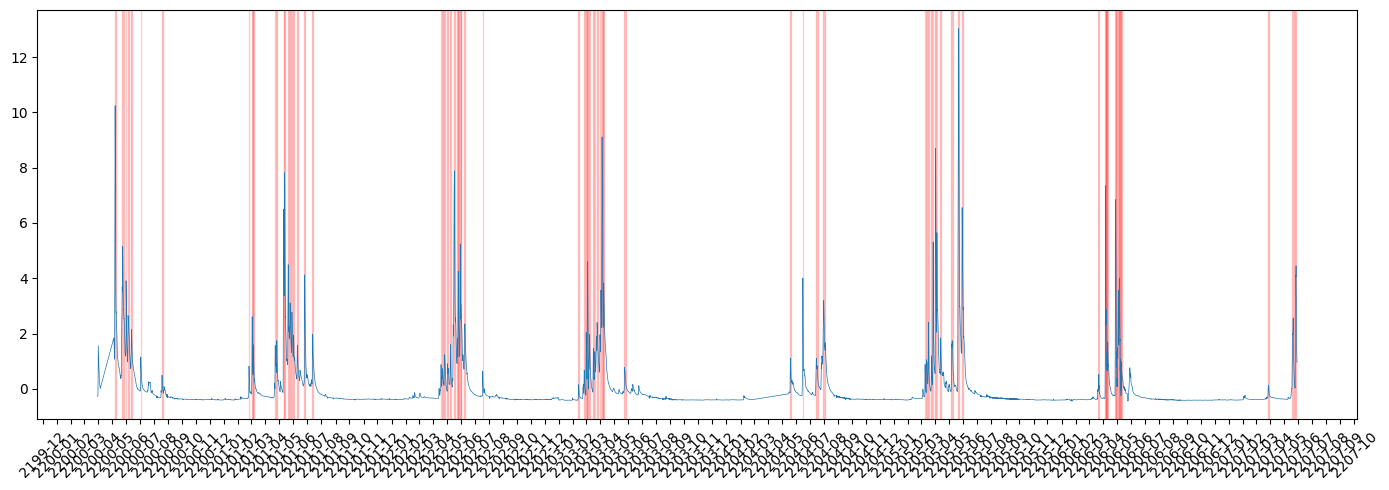

# Epoch 1: 100%|██████████| 38/38 [00:10<00:00,  3.73it/s, Loss: 0.0000]
2026-04-15 01:52:09,708: Epoch 1 average loss: avg_loss: 2.50e-06, avg_total_loss: 2.50e-06
# Epoch 2: 100%|██████████| 38/38 [00:09<00:00,  3.96it/s, Loss: 0.0000]
2026-04-15 01:52:19,310: Epoch 2 average loss: avg_loss: 1.98e-06, avg_total_loss: 1.98e-06
# Epoch 3: 100%|██████████| 38/38 [00:10<00:00,  3.71it/s, Loss: 0.0000]
2026-04-15 01:52:29,561: Epoch 3 average loss: avg_loss: 2.01e-06, avg_total_loss: 2.01e-06
# Validation: 100%|██████████| 1/1 [00:09<00:00,  9.95s/it]
2026-04-15 01:52:39,531: Best checkpoint saved at epoch 3 (val_loss=4.10e-08)
2026-04-15 01:52:39,531: Epoch 3 average validation loss: 4.10e-08 -- Median validation metrics: avg_loss: 4.10e-08, NSE_1H: 0.39661, MSE_1H: 28557350.00000, NSE_1D: 0.73800, MSE_1D: 11839638.00000
2026-04-15 01:52:39,531: ES[plateau]: epoch=3, lr=1.00e-02, val_loss=0.000000 (warmup, min_epoch=24)
# Epoch 4: 100%|██████████| 38/38 [00:09<00:00,  3.82it/s, Loss: 0.0

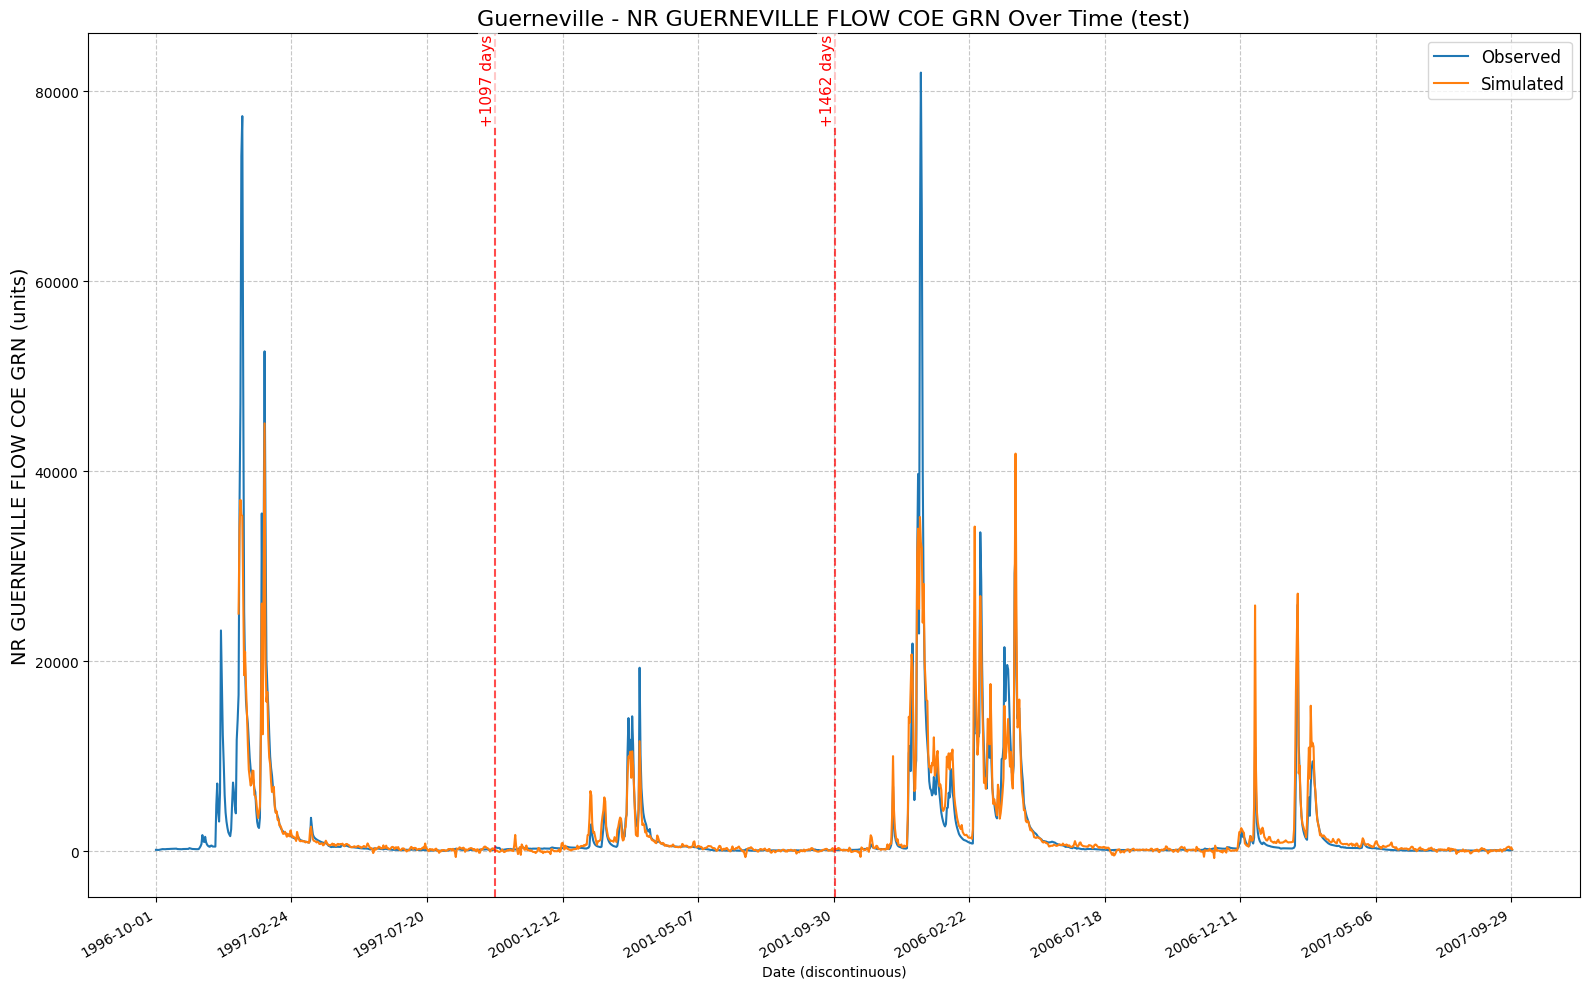

[UCB_trainer] Restoring synthetic test dates for analysis...
[UCB_trainer] _observed restored coord 'date': 1996-10-01 00:00:00 → 2007-09-30 00:00:00
[UCB_trainer] _predictions restored coord 'date': 1996-10-01 00:00:00 → 2007-09-30 00:00:00


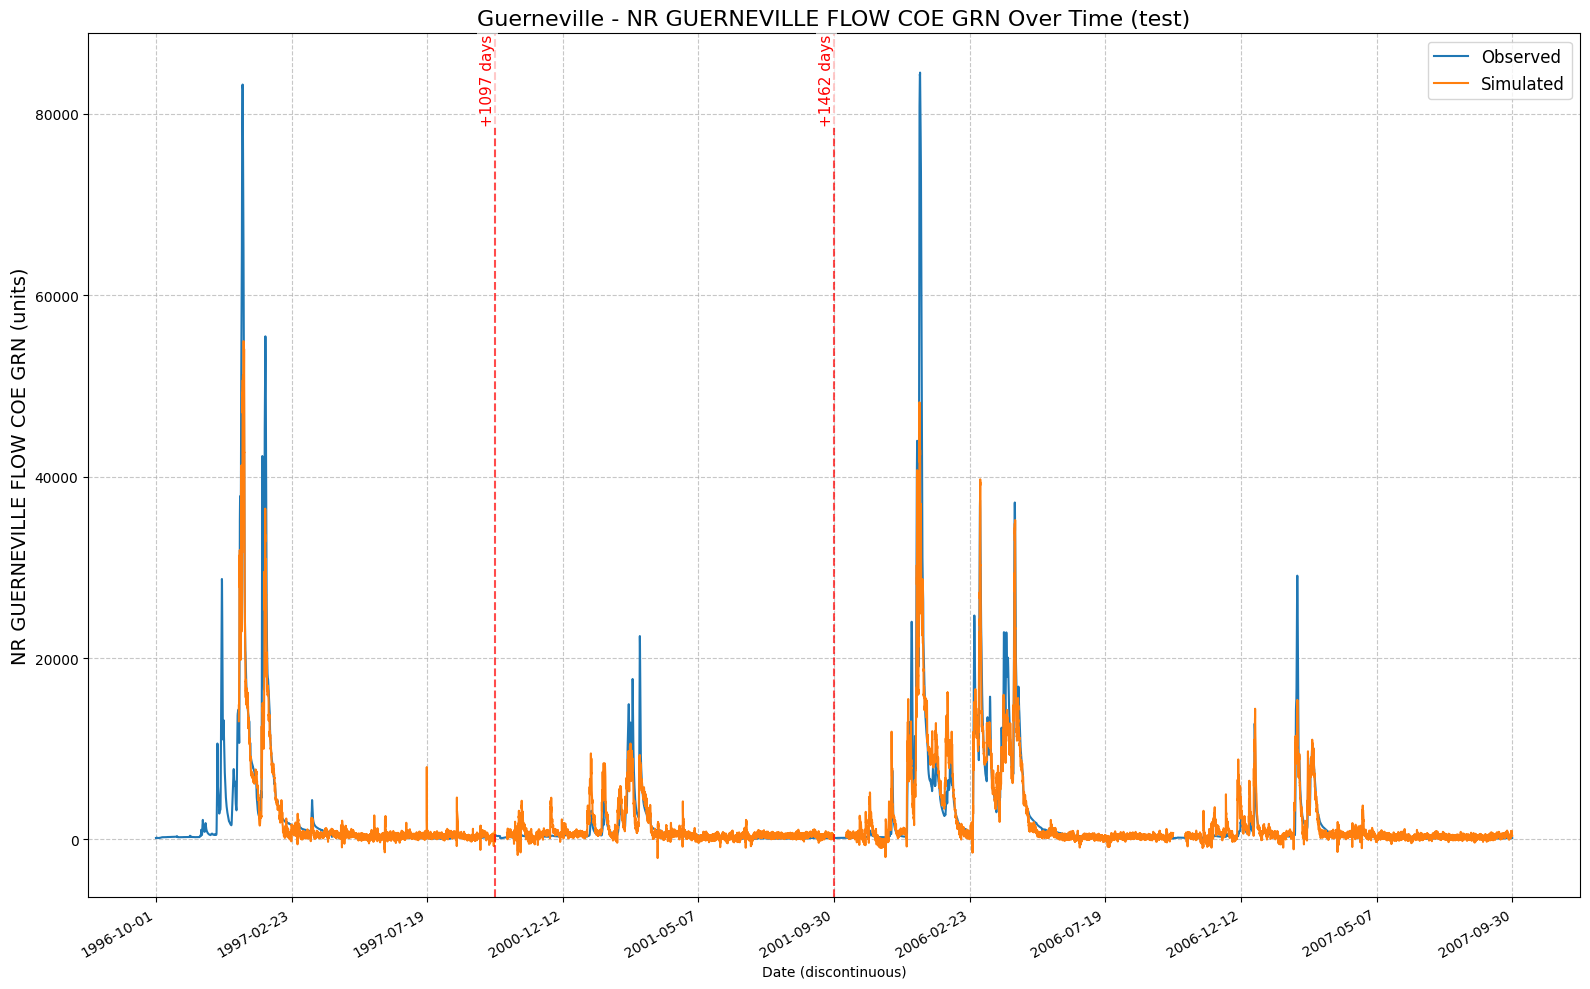


[No-Physics Test] NSE @1D = 0.8124450955685486
[No-Physics Test] NSE @1H = 0.8077381863239395


In [25]:
if not skip_best_model_test:
    print("\nTraining No-Physics mts model for test period...")
    mtsNoPhysicsTest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_no_physics_params,
        input_features=None,
        physics_informed=False,
        physics_data_file=None,
        hourly=True,
        extend_train_period=True,
        gpu=GPU_SETTING,
        num_ensemble_members = NUM_ENSEMBLES_FINAL,
        hyperparam_ensemble = HYPERPARAM_ENSEMBLE,
        bootstrap_model = BOOTSTRAP_MODELS,
        is_mts = True,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP,
        experiment_tag="no_phys_test")

    ensure_absolute_basin_files(mtsNoPhysicsTest, BASIN)
    
    mtsNoPhysicsTest.train()

    no_physics_test_csv_1D, no_physics_test_metrics_1D = mtsNoPhysicsTest.results(period="test", mts_trk="1D")
    no_physics_test_csv_1H, no_physics_test_metrics_1H = mtsNoPhysicsTest.results(period="test", mts_trk="1H")
    print("\n[No-Physics Test] NSE @1D =", no_physics_test_metrics_1D.get("NSE", None))
    print("[No-Physics Test] NSE @1H =", no_physics_test_metrics_1H.get("NSE", None))


Training Physics MTS model for test period...
[UCB Trainer] Using CPU (unhandled gpu=-1).
2026-04-15 02:20:50,379: Logging to /Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/guerneville/mts_shared/runs/PEAK_NSE_PENALTY_V2_20260415T085149Z/testing_run_1504_022050/output.log initialized.
2026-04-15 02:20:50,379: ### Folder structure created at /Users/maxwellfung/UCB-USACE-RR-PROJECT/outputs/guerneville/mts_shared/runs/PEAK_NSE_PENALTY_V2_20260415T085149Z/testing_run_1504_022050
2026-04-15 02:20:50,379: ### Run configurations for testing_run
2026-04-15 02:20:50,379: experiment_name: testing_run
2026-04-15 02:20:50,380: train_basin_file: /Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville/guerneville
2026-04-15 02:20:50,380: validation_basin_file: /Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville/guerneville
2026-04-15 02:20:50,380: test_basin_file: /Users/maxwellfung/UCB-USACE-RR-PROJECT/notebooks/basins/guerneville/guerneville
2026-04-15 02:20:50,380:

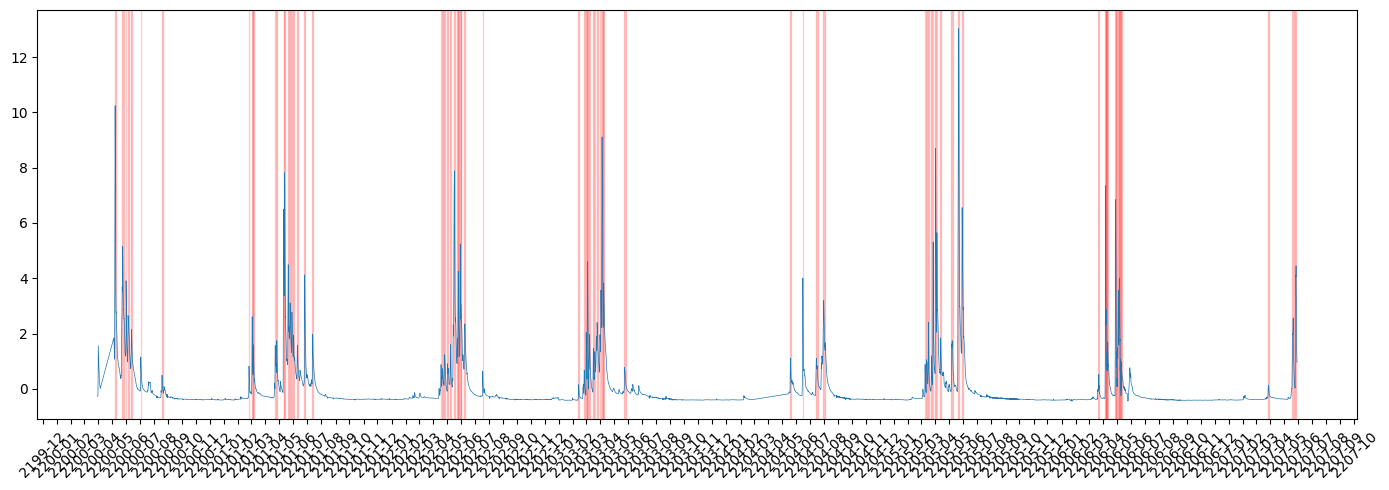

# Epoch 1: 100%|██████████| 38/38 [00:10<00:00,  3.57it/s, Loss: 0.0000]
2026-04-15 02:21:19,935: Epoch 1 average loss: avg_loss: 2.35e-07, avg_total_loss: 2.35e-07
# Epoch 2: 100%|██████████| 38/38 [00:10<00:00,  3.50it/s, Loss: 0.0000]
2026-04-15 02:21:30,806: Epoch 2 average loss: avg_loss: 1.34e-07, avg_total_loss: 1.34e-07
# Epoch 3: 100%|██████████| 38/38 [00:10<00:00,  3.62it/s, Loss: 0.0000]
2026-04-15 02:21:41,292: Epoch 3 average loss: avg_loss: 1.32e-07, avg_total_loss: 1.32e-07
# Validation: 100%|██████████| 1/1 [00:18<00:00, 18.70s/it]
2026-04-15 02:22:00,011: Best checkpoint saved at epoch 3 (val_loss=1.14e-08)
2026-04-15 02:22:00,012: Epoch 3 average validation loss: 1.14e-08 -- Median validation metrics: avg_loss: 1.14e-08, NSE_1H: 0.84931, MSE_1H: 7131785.50000, NSE_1D: 0.90447, MSE_1D: 4317097.50000
2026-04-15 02:22:00,012: ES[plateau]: epoch=3, lr=1.00e-02, val_loss=0.000000 (warmup, min_epoch=24)
# Epoch 4: 100%|██████████| 38/38 [00:10<00:00,  3.79it/s, Loss: 0.000

In [ ]:
if not skip_best_model_test:
    print("\nTraining Physics MTS model for test period...")
    mtsPhysicsTest = UCB_trainer(
        path_to_csv_folder=path_to_csv,
        yaml_path=path_to_yaml,
        hyperparams=best_physics_params,
        input_features=features_with_physics,
        physics_informed=True,
        physics_data_file=path_to_physics_data_1H,
        hourly=True,
        extend_train_period=True,
        gpu=GPU_SETTING,
        num_ensemble_members = NUM_ENSEMBLES_FINAL,
        hyperparam_ensemble = HYPERPARAM_ENSEMBLE,
        bootstrap_model = BOOTSTRAP_MODELS,
        is_mts = True,
        verbose=verbose,
        runs_parent=RUNS_PARENT,
        run_label=RUN_LABEL,
        run_stamp=RUN_STAMP,
        experiment_tag="phys_test")

    ensure_absolute_basin_files(mtsPhysicsTest, BASIN)

    mtsPhysicsTest.train()
    physics_test_csv_1D, physics_test_metrics_1D = mtsPhysicsTest.results(period="test", mts_trk="1D")
    physics_test_csv_1H, physics_test_metrics_1H = mtsPhysicsTest.results(period="test", mts_trk="1H")
    print("\n[Physics Test] NSE @1D =", physics_test_metrics_1D.get("NSE", None))
    print("[Physics Test] NSE @1H =", physics_test_metrics_1H.get("NSE", None))

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Guerneville Basin MTS 1D Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_test_metrics_1D.csv", ts_out="guerneville_mts_test_1D_combined_ts.csv", fig_out="guerneville_mts_test_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    combined_df_test_1D = read_csv_artifact("guerneville_mts_test_1D_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
    plot_timeseries_comparison(source=combined_df_test_1D, title="Guerneville Basin MTS 1D Model Comparison (Test)", backend="mpl", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_test_metrics_1D.csv", ts_out="guerneville_mts_test_1D_combined_ts.csv", fig_out="guerneville_mts_test_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Guerneville Basin MTS 1D Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_test_metrics_1D.csv", ts_out="guerneville_mts_test_1D_combined_ts.csv", fig_out="guerneville_mts_test_1D_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Guerneville Basin MTS 1D Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_test_metrics_1D.csv", ts_out="guerneville_mts_test_1D_combined_ts.csv", fig_out="guerneville_mts_test_1D_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Guerneville Basin MTS 1H Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_test_metrics_1H.csv", ts_out="guerneville_mts_test_1H_combined_ts.csv", fig_out="guerneville_mts_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Guerneville Basin MTS 1H Model Comparison (Test)", backend="plotly", metrics=["NSE", "PBIAS"], metrics_out="guerneville_mts_test_metrics_1H.csv", ts_out="guerneville_mts_test_1H_combined_ts.csv", fig_out="guerneville_mts_test_1H_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

test_metrics = read_csv_artifact("guerneville_mts_test_metrics_1D.csv", kind="metrics", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
print(test_metrics)

In [ ]:
switch_ctx(RES_1H)s

test_metrics = read_csv_artifact("guerneville_mts_test_metrics_1H.csv", kind="metrics", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
print(test_metrics)

In [ ]:
if not skip_best_model_validation and not use_cv_for_selection:
    write_paths("no_physics_val", noPhysValTrainer, filename = RUNS_FILE)
    write_paths("physics_val", physValTrainer, filename = RUNS_FILE)

if not skip_best_model_test:
    write_paths("no_physics", mtsNoPhysicsTest, filename = RUNS_FILE)
    write_paths("physics", mtsPhysicsTest, filename = RUNS_FILE)
    archived_path = archive_runs_json(Path(RUNS_FILE), BASIN, MODE, RUN_LABEL, RUN_STAMP)

In [ ]:
end_time = datetime.utcnow()
print("End time:", end_time.strftime("%Y-%m-%d %H:%M:%S"))
print("total time:", end_time - start_time)

##### Additional plots

In [ ]:
if skip_best_model_validation and not use_cv_for_selection:
    switch_ctx(RES_1D)
    combined_df_daily_val = read_csv_artifact("guerneville_mts_val_1D_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)

    switch_ctx(RES_1H)
    combined_df_hourly_val = read_csv_artifact("guerneville_mts_val_1H_combined_ts.csv", kind="csv", period="validation", stamp = READ_STAMP, run_label = RUN_LABEL)

if skip_best_model_test:
    switch_ctx(RES_1D)
    combined_df_daily = read_csv_artifact("guerneville_mts_test_1D_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)
    switch_ctx(RES_1H)
    combined_df_hourly = read_csv_artifact("guerneville_mts_test_1H_combined_ts.csv", kind="csv", period="test", stamp = READ_STAMP, run_label = RUN_LABEL)

In [ ]:
metric_list = ["NSE", "PBIAS"]

wettest_start_val = "2003-10-01"
wettest_end_val = "2004-09-30"
dryest_start_val = "2004-10-01"
dryest_end_val = "2005-09-30"
wettest_start_test = "2005-10-01"
wettest_end_test = "2006-09-30"
dryest_start_test = "2008-10-01"
dryest_end_test = "2009-09-30"

In [ ]:
switch_ctx(RES_1D)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_mts_val_metrics_1D.csv", ts_out="guerneville_mts_val_1D_combined_ts.csv", fig_out="guerneville_mts_val_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_daily_val, title="Guerneville Daily MTS Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_mts_val_metrics_1D.csv", ts_out="guerneville_mts_val_1D_combined_ts.csv", fig_out="guerneville_mts_val_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_mts_val_metrics_1H.csv", ts_out="guerneville_mts_val_1H_combined_ts.csv", fig_out="guerneville_mts_val_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_hourly_val, title="Guerneville Hourly MTS Validation Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_mts_val_metrics_1H.csv", ts_out="guerneville_mts_val_1H_combined_ts.csv", fig_out="guerneville_mts_val_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_mts_test_metrics_1D.csv", ts_out="guerneville_mts_test_1D_combined_ts.csv", fig_out="guerneville_mts_test_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Guerneville Daily MTS Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_mts_test_metrics_1D.csv", ts_out="guerneville_mts_test_1D_combined_ts.csv", fig_out="guerneville_mts_test_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Test Timeseries - Interactive", backend="plotly", metrics=metric_list, metrics_out="guerneville_mts_test_metrics_1D.csv", ts_out="guerneville_mts_test_1D_combined_ts.csv", fig_out="guerneville_mts_test_1D_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Guerneville Daily MTS Test Timeseries - Interactive", backend="plotly", metrics=metric_list, metrics_out="guerneville_mts_test_metrics_1D.csv", ts_out="guerneville_mts_test_1D_combined_ts.csv", fig_out="guerneville_mts_test_1D_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_mts_test_metrics_1H.csv", ts_out="guerneville_mts_test_1H_combined_ts.csv", fig_out="guerneville_mts_test_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Guerneville Hourly MTS Test Timeseries", backend="mpl", metrics=metric_list, metrics_out="guerneville_mts_test_metrics_1H.csv", ts_out="guerneville_mts_test_1H_combined_ts.csv", fig_out="guerneville_mts_test_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Test Timeseries - Interactive", backend="plotly", metrics=metric_list, metrics_out="guerneville_mts_test_metrics_1H.csv", ts_out="guerneville_mts_test_1H_combined_ts.csv", fig_out="guerneville_mts_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Guerneville Hourly MTS Test Timeseries - Interactive", backend="plotly", metrics=metric_list, metrics_out="guerneville_mts_test_metrics_1H.csv", ts_out="guerneville_mts_test_1H_combined_ts.csv", fig_out="guerneville_mts_test_1H_model_comparison.png", legend_font=12, axis_font=22)

##### Ensemble Performance Overview

In [ ]:
if NUM_ENSEMBLES_FINAL > 1:
    import numpy as np

    def load_hms(path, basin_name="calpella"):
        path = Path(path)
        print("\nLoading HMS from:")
        print(path)

        raw = pd.read_csv(path, header=None, dtype=str)

        hdr = raw.apply(lambda r: r.str.contains("date", case=False, na=False).any(), axis=1).idxmax()

        df = raw.iloc[hdr:].copy()
        df.columns = df.iloc[0].str.strip().str.lower()
        df = df.iloc[1:].copy()

        df.columns = [c.strip().lower() for c in df.columns]

        date_col = next((c for c in df.columns if "date" in c), None)
        time_col = next((c for c in df.columns if "time" in c), None)

        if date_col is None:
            raise RuntimeError("No Date column found in HMS CSV")

        if time_col is not None and df[time_col].notna().any():

            df[time_col] = df[time_col].fillna("00:00:00").str.strip()

            mask24 = df[time_col] == "24:00:00"
            if mask24.any():
                df.loc[mask24, date_col] = (
                    pd.to_datetime(df.loc[mask24, date_col], format="%d-%b-%y")
                    + pd.Timedelta(days=1)
                ).dt.strftime("%d-%b-%y")
                df.loc[mask24, time_col] = "00:00:00"

            df["date"] = (
                pd.to_datetime(df[date_col], format="%d-%b-%y", errors="coerce") +
                pd.to_timedelta(df[time_col])
            )

        else:
            df["date"] = pd.to_datetime(df[date_col], format="%d-%b-%y", errors="coerce")

        df.dropna(subset=["date"], inplace=True)

        basin_cols = [c for c in df.columns if "basin" in c]
        if basin_cols:
            bc = basin_cols[0]
            print(f"Filtering by basin column: {bc}")
            df = df[df[bc].astype(str).str.lower().str.contains(basin_name)]

        df = df.sort_values("date").reset_index(drop=True)

        print("Rows:", len(df))
        print("Columns:", list(df.columns))

        return df

    def load_hms_simple(path):
        df = load_hms(path)

        flow_col = next(c for c in df.columns if "gage flow" in c.lower())

        df = df[["date", flow_col]].rename(columns={
            "date": "Date",
            flow_col: "HMS"
        })

        df["Date"] = pd.to_datetime(df["Date"]).dt.floor("H")

        return df


    def nse(obs, sim):
        obs = np.asarray(obs, dtype=float)
        sim = np.asarray(sim, dtype=float)

        mask = np.isfinite(obs) & np.isfinite(sim)
        obs = obs[mask]
        sim = sim[mask]

        return 1 - np.sum((sim - obs)**2) / np.sum((obs - obs.mean())**2)


    def load_ensemble_mean(folder, split, freq):

        dfs = []

        for m in sorted(folder.glob("member_*")):
            p = m / f"{split.lower()}_{freq}.csv"
            if not p.exists():
                continue

            df = pd.read_csv(p, parse_dates=["Date"])

            df = df[["Date", "Predicted", "Observed"]]

            df["Predicted"] = pd.to_numeric(df["Predicted"], errors="coerce")
            df["Observed"] = pd.to_numeric(df["Observed"], errors="coerce")

            df = df.rename(columns={"Predicted": m.name})

            dfs.append(df)

        if not dfs:
            raise RuntimeError(f"No ensemble CSVs in {folder}")

        merged = dfs[0]

        for df in dfs[1:]:
            merged = merged.merge(df, on=["Date", "Observed"], how="inner")

        member_cols = [c for c in merged.columns if c not in ["Date", "Observed"]]

        merged["ensemble"] = merged[member_cols].mean(axis=1)

        merged = merged.dropna(subset=["Observed", "ensemble"])

        return merged[["Date", "Observed", "ensemble"]]


    def eval_split(split, freq, folder, hms_df):

        df = load_ensemble_mean(folder, split, freq)

        df = df.merge(hms_df, on="Date", how="inner")

        df["HMS"] = pd.to_numeric(df["HMS"], errors="coerce")

        df = df.dropna(subset=["Observed", "ensemble", "HMS"])

        print(f"{split}-{freq}: rows used = {len(df)}")

        return {
            "HMS": nse(df["Observed"].values, df["HMS"].values),
            "MODEL": nse(df["Observed"].values, df["ensemble"].values)
        }

    def eval_single_member(no_phys_folder, phys_folder, split, freq, hms_df, member_name):

        def load_member(folder):
            p = folder / member_name / f"{split.lower()}_{freq}.csv"
            if not p.exists():
                raise RuntimeError(f"Missing {p}")

            df = pd.read_csv(p, parse_dates=["Date"])
            df = df[["Date", "Predicted", "Observed"]]

            df["Predicted"] = pd.to_numeric(df["Predicted"], errors="coerce")
            df["Observed"] = pd.to_numeric(df["Observed"], errors="coerce")

            return df

        # LSTM (no physics)
        df_lstm = load_member(no_phys_folder)

        # PI LSTM
        df_pi = load_member(phys_folder).rename(columns={"Predicted": "PI"})

        df = df_lstm.merge(df_pi[["Date", "PI"]], on="Date", how="inner")
        df = df.merge(hms_df, on="Date", how="inner")

        df["HMS"] = pd.to_numeric(df["HMS"], errors="coerce")

        df = df.dropna(subset=["Observed", "Predicted", "PI", "HMS"])

        return {
            "HMS": nse(df["Observed"], df["HMS"]),
            "LSTM": nse(df["Observed"], df["Predicted"]),
            "PI": nse(df["Observed"], df["PI"])
        }

    from sklearn.linear_model import Ridge
    import numpy as np

    def fit_ridge_weights(val_pred_matrix, y_val, alpha=1.0, nonneg=False):
        """
        val_pred_matrix: shape (T, M)
        y_val: shape (T,)
        Returns weights shape (M,)
        """
        model = Ridge(alpha=alpha, fit_intercept=False)
        model.fit(val_pred_matrix, y_val)
        w = model.coef_.copy()

        if nonneg:
            w = np.maximum(w, 0)

        # normalize to sum to 1 for stability
        if w.sum() != 0:
            w = w / w.sum()

        return w

    def load_member_matrix(folder, split, freq):
        dfs = []
        names = []
        for m in sorted(folder.glob("member_*")):
            p = m / f"{split.lower()}_{freq}.csv"
            if not p.exists():
                continue
            df = pd.read_csv(p, parse_dates=["Date"])[["Date", "Predicted", "Observed"]]
            df["Predicted"] = pd.to_numeric(df["Predicted"], errors="coerce")
            df["Observed"] = pd.to_numeric(df["Observed"], errors="coerce")
            df = df.dropna(subset=["Predicted", "Observed"])
            df = df.rename(columns={"Predicted": m.name})
            dfs.append(df)
            names.append(m.name)

        merged = dfs[0]
        for df in dfs[1:]:
            merged = merged.merge(df, on=["Date", "Observed"], how="inner")

        X = merged[names].values  # (T, M)
        y = merged["Observed"].values
        dates = merged["Date"].values
        return dates, y, X, names

    def eval_ridge_weighted(val_folder, test_folder, freq, hms_df, alpha=1.0):
        # fit on validation
        _, y_val, X_val, names = load_member_matrix(val_folder, "Validation", freq)
        w = fit_ridge_weights(X_val, y_val, alpha=alpha, nonneg=True)

        # apply to test
        dates_t, y_t, X_t, _ = load_member_matrix(test_folder, "Test", freq)
        y_hat = X_t @ w

        df = pd.DataFrame({"Date": pd.to_datetime(dates_t), "Observed": y_t, "ensemble": y_hat})
        df = df.merge(hms_df, on="Date", how="inner").dropna()

        return w, {
            "HMS": nse(df["Observed"], df["HMS"]),
            "MODEL": nse(df["Observed"], df["ensemble"])
        }, names

    ROOT = Path(RUNS_PARENT, "ensemble_predictions/BASELINE")

    folders = {
        "phys_validation": ROOT / "phys_validation",
        "no_phys_validation": ROOT / "no_phys_validation",
        "phys_test": ROOT / "phys_test",
        "no_phys_test": ROOT / "no_phys_test",
    }

    HMS_1D = path_to_physics_data_1D
    HMS_1H = path_to_physics_data_1H
    hms1d = load_hms_simple(HMS_1D)
    hms1h = load_hms_simple(HMS_1H)

    members = ["member_01", "member_02",  "member_03",  "member_04",  "member_05"]

    member_tables = {m: [] for m in members}
    ensemble_results = {}

    for split in ["Validation", "Test"]:
        for freq, hms_df in [("1D", hms1d), ("1H", hms1h)]:

            no_phys = folders[f"no_phys_{split.lower()}"]
            phys = folders[f"phys_{split.lower()}"]

            for m in members:
                r = eval_single_member(no_phys, phys, split, freq, hms_df, m)

                member_tables[m].append([
                    f"{split} - {freq}",
                    round(r["HMS"], 3),
                    round(r["LSTM"], 3),
                    round(r["PI"], 3)
                ])

            lstm = eval_split(split, freq, no_phys, hms_df)
            pi   = eval_split(split, freq, phys, hms_df)

            ensemble_results[f"{split}-{freq}"] = {
                "HMS": lstm["HMS"],
                "LSTM": lstm["MODEL"],
                "PI": pi["MODEL"]
            }

    # ================= MEMBER TABLES =================

    for m in members:
        print(f"\n========= NSE TABLE FOR {m.upper()} =========\n")

        df_m = pd.DataFrame(
            member_tables[m],
            columns=["Run Type", "HMS Prediction", "LSTM Prediction", "PI LSTM Prediction"]
        )

        display(df_m)

    # ================= COMBINED TABLE =================

    rows = []

    for k in ["Validation-1D","Validation-1H","Test-1D","Test-1H"]:
        r = ensemble_results[k]
        rows.append([
            k.replace("-", " - "),
            round(r["HMS"],3),
            round(r["LSTM"],3),
            round(r["PI"],3)
        ])

    df_out = pd.DataFrame(
        rows,
        columns=["Run Type","HMS Prediction","LSTM Prediction","PI LSTM Prediction"]
    )

    print("\n========= COMBINED ENSEMBLE NSE TABLE =========\n")
    display(df_out)

    # ================= VALIDATION WEIGHTS =================

    rows = []
    for freq, hms_df in [("1D", hms1d), ("1H", hms1h)]:
        # LSTM (no-phys)
        w_lstm, res_lstm, names_lstm = eval_ridge_weighted(
            folders["no_phys_validation"], folders["no_phys_test"], freq, hms_df, alpha=10.0
        )

        # PI (phys)
        w_pi, res_pi, names_pi = eval_ridge_weighted(
            folders["phys_validation"], folders["phys_test"], freq, hms_df, alpha=10.0
        )

        rows.append([
            f"Test - {freq}",
            round(res_lstm["HMS"], 3),
            round(res_lstm["MODEL"], 3),
            round(res_pi["MODEL"], 3),
            {n: round(float(w), 3) for n, w in zip(names_lstm, w_lstm)},
            {n: round(float(w), 3) for n, w in zip(names_pi, w_pi)},
        ])

    df_ridge = pd.DataFrame(rows, columns=[
        "Run Type", "HMS Prediction", "Ridge-Weighted LSTM", "Ridge-Weighted PI LSTM",
        "LSTM Weights", "PI Weights"
    ])

    print("\n========= RIDGE-LEARNED WEIGHTS (VAL → TEST) =========\n")
    display(df_ridge)

In [ ]:
# EVERYTHING BELOW HERE MEASURES EXTREME YEARS.
# 
# raise SystemExit("EVERYTHING BELOW HERE MEASURES EXTREME YEARS WITH HARDCODED VALUES AND DOESNT MAKE SENSE FOR SYNTHETIC")

##### Wettest Year Performance

In [ ]:
switch_ctx(RES_1D)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="guerneville_mts_wet_val_metrics_1D.csv", ts_out="guerneville_mts_wet_val_1D_combined_ts.csv", fig_out="guerneville_mts_wet_val_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_daily_val, title="Guerneville Daily MTS Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="guerneville_mts_wet_val_metrics_1D.csv", ts_out="guerneville_mts_wet_val_1D_combined_ts.csv", fig_out="guerneville_mts_wet_val_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="guerneville_mts_wet_val_metrics_1H.csv", ts_out="guerneville_mts_wet_val_1H_combined_ts.csv", fig_out="guerneville_mts_wet_val_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_hourly_val, title="Guerneville Hourly MTS Wettest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_val, end_date=wettest_end_val, metrics_out="guerneville_mts_wet_val_metrics_1H.csv", ts_out="guerneville_mts_wet_val_1H_combined_ts.csv", fig_out="guerneville_mts_wet_val_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_mts_wet_test_metrics_1D.csv", ts_out="guerneville_mts_wet_test_1D_combined_ts.csv", fig_out="guerneville_mts_wet_test_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Guerneville Daily MTS Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_mts_wet_test_metrics_1D.csv", ts_out="guerneville_mts_wet_test_1D_combined_ts.csv", fig_out="guerneville_mts_wet_test_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Wettest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_mts_wet_test_metrics_1D.csv", ts_out="guerneville_mts_wet_test_1D_combined_ts.csv", fig_out="guerneville_mts_wet_test_1D_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Guerneville Daily MTS Wettest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_mts_wet_test_metrics_1D.csv", ts_out="guerneville_mts_wet_test_1D_combined_ts.csv", fig_out="guerneville_mts_wet_test_1D_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_mts_wet_test_metrics_1H.csv", ts_out="guerneville_mts_wet_test_1H_combined_ts.csv", fig_out="guerneville_mts_wet_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Guerneville Hourly MTS Wettest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_mts_wet_test_metrics_1H.csv", ts_out="guerneville_mts_wet_test_1H_combined_ts.csv", fig_out="guerneville_mts_wet_test_1H_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Wettest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_mts_wet_test_metrics_1H.csv", ts_out="guerneville_mts_wet_test_1H_combined_ts.csv", fig_out="guerneville_mts_wet_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Guerneville Hourly MTS Wettest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=wettest_start_test, end_date=wettest_end_test, metrics_out="guerneville_mts_wet_test_metrics_1H.csv", ts_out="guerneville_mts_wet_test_1H_combined_ts.csv", fig_out="guerneville_mts_wet_test_1H_model_comparison.png", legend_font=12, axis_font=22)

##### Dryest Year Performance

In [ ]:
switch_ctx(RES_1D)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="guerneville_mts_dry_val_metrics_1D.csv", ts_out="guerneville_mts_dry_val_1D_combined_ts.csv", fig_out="guerneville_mts_dry_val_1D_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_daily_val, title="Guerneville Daily MTS Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="guerneville_mts_dry_val_metrics_1D.csv", ts_out="guerneville_mts_dry_val_1D_combined_ts.csv", fig_out="guerneville_mts_dry_val_1D_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    plot_timeseries_comparison(source=(noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="guerneville_mts_dry_val_metrics_1H.csv", ts_out="guerneville_mts_dry_val_1H_combined_ts.csv", fig_out="guerneville_mts_dry_val_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_hourly_val, title="Guerneville Hourly MTS Dryest Year Validation Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_val, end_date=dryest_end_val, metrics_out="guerneville_mts_dry_val_metrics_1H.csv", ts_out="guerneville_mts_dry_val_1H_combined_ts.csv", fig_out="guerneville_mts_dry_val_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Dryest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_mts_dry_test_metrics_1D.csv", ts_out="guerneville_mts_dry_test_ts_1D.csv", fig_out="guerneville_mts_dry_test_plot_1D.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Guerneville Daily MTS Dryest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_mts_dry_test_metrics_1D.csv", ts_out="guerneville_mts_dry_test_ts_1D.csv", fig_out="guerneville_mts_dry_test_plot_1D.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), title="Guerneville Daily MTS Dryest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_mts_dry_test_metrics_1D.csv", ts_out="guerneville_mts_dry_test_1D_combined_ts.csv", fig_out="guerneville_mts_dry_test_1D_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1D, title="Guerneville Daily MTS Dryest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_mts_dry_test_metrics_1D.csv", ts_out="guerneville_mts_dry_test_1D_combined_ts.csv", fig_out="guerneville_mts_dry_test_1D_model_comparison.png", legend_font=12, axis_font=22)

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Dryest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_mts_dry_test_metrics_1H.csv", ts_out="guerneville_mts_dry_test_1H_combined_ts.csv", fig_out="guerneville_mts_dry_test_1H_model_comparison.png", legend_font=20, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Guerneville Hourly MTS Dryest Year Test Timeseries", backend="mpl", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_mts_dry_test_metrics_1H.csv", ts_out="guerneville_mts_dry_test_1H_combined_ts.csv", fig_out="guerneville_mts_dry_test_1H_model_comparison.png", legend_font=20, axis_font=22)

In [ ]:
if not skip_best_model_test:
    plot_timeseries_comparison(source=(no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), title="Guerneville Hourly MTS Dryest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_mts_dry_test_metrics_1H.csv", ts_out="guerneville_mts_dry_test_1H_combined_ts.csv", fig_out="guerneville_mts_dry_test_1H_model_comparison.png", legend_font=12, axis_font=22)
else:
    plot_timeseries_comparison(source=combined_df_test_1H, title="Guerneville Hourly MTS Dryest Year Test Timeseries - Interactive", backend="plotly", metrics=metric_list, start_date=dryest_start_test, end_date=dryest_end_test, metrics_out="guerneville_mts_dry_test_metrics_1H.csv", ts_out="guerneville_mts_dry_test_1H_combined_ts.csv", fig_out="guerneville_mts_dry_test_1H_model_comparison.png", legend_font=12, axis_font=22)

##### Gridded Timeseries Plots - Validation & Test

In [ ]:
switch_ctx(RES_1D)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    ts_triptych_v3((noPhys_val_csv_1D, phys_val_csv_1D, path_to_physics_data_1D),wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="guerneville_mts_daily_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Guerneville MTS Daily Validation Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Validation period","Most-wet water-year","Most-dry water-year"))

else:
    ts_triptych_v3(combined_df_daily_val, wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val,dry_end=dryest_end_val, save_path="guerneville_mts_daily_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Guerneville MTS Daily Validation Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Validation Period", "Most‑wet water‑year", "Most‑dry water‑year"))

In [ ]:
switch_ctx(RES_1H)

if use_cv_for_selection:
    pass  # No validation period in CV mode
elif not skip_best_model_validation:
    ts_triptych_v3((noPhys_val_csv_1H, phys_val_csv_1H, path_to_physics_data_1H), wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="guerneville_mts_hourly_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Guerneville MTS Hourly Validation Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Validation period","Most-wet water-year","Most-dry water-year"))
    
else:
    ts_triptych_v3(combined_df_hourly_val, wet_start=wettest_start_val, wet_end=wettest_end_val, dry_start=dryest_start_val, dry_end=dryest_end_val, save_path="guerneville_mts_hourly_TS_validation.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Guerneville MTS Hourly Validation Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Validation Period", "Most‑wet water‑year", "Most‑dry water‑year"))

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    ts_triptych_v3((no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="guerneville_mts_daily_TS_test.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Guerneville MTS Daily Test Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Test period","Most-wet water-year","Most-dry water-year"))
    
else:
    ts_triptych_v3(combined_df_daily, wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="guerneville_mts_daily_TS_test.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Guerneville MTS Daily Test Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Test Period", "Most‑wet water‑year", "Most‑dry water‑year"))

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    ts_triptych_v3((no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="guerneville_mts_hourly_TS_test.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d-%b-%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title="Guerneville MTS Hourly Test Period Timeseries Across Models", main_title_font=14, main_title_y=0.99, main_title_pad=0.05, row_titles=("Full Test period","Most-wet water-year","Most-dry water-year"))
    
else:
    ts_triptych_v3(combined_df_hourly, wet_start=wettest_start_test, wet_end=wettest_end_test, dry_start=dryest_start_test, dry_end=dryest_end_test, save_path="guerneville_mts_hourly_TS_test.png", legend_font=12, legend_boxpad=0.5, axis_font=12, date_fmt="%d‑%b‑%Y", figsize=(10, 10), dpi=600, hspace=0.2, main_title = "Guerneville MTS Hourly Test Timeseries Across Models", main_title_font=14, main_title_y = 0.99, main_title_pad = 0.05, row_titles=("Full Test Period", "Most‑wet water‑year","Most‑dry water‑year"))

##### Gridded Scatter Plots - Test

In [ ]:
switch_ctx(RES_1D)

if not skip_best_model_test:
    scatter_triptych_pngs_v3((no_physics_test_csv_1D, physics_test_csv_1D, path_to_physics_data_1D), wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test, dry_end = dryest_end_test, out_dir = "guerneville_mts_daily_scatter", layout = "horizontal", square_side = 4.5, legend_font  = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Guerneville MTS Daily – Full test period", "Guerneville MTS Daily – Wettest water‑year", "Guerneville MTS Daily – Driest water‑year"), resolution="mts_daily")
    
else:
    scatter_pngs = scatter_triptych_pngs_v3(combined_df_daily, wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test, dry_end = dryest_end_test, out_dir = "guerneville_mts_daily_scatter", layout = "horizontal", square_side = 4.5,legend_font  = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Guerneville MTS Daily – Full test period", "Guerneville MTS Daily – Wettest water‑year", "Guerneville MTS Daily – Driest water‑year"), resolution="mts_daily")

In [ ]:
switch_ctx(RES_1H)

if not skip_best_model_test:
    scatter_triptych_pngs_v3((no_physics_test_csv_1H, physics_test_csv_1H, path_to_physics_data_1H), wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test, dry_end = dryest_end_test, out_dir = "guerneville_mts_hourly_scatter", layout = "horizontal", square_side = 4.5, legend_font = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Guerneville MTS Hourly – Full test period", "Guerneville MTS Hourly – Wettest water‑year", "Guerneville MTS Hourly – Driest water‑year"), resolution="mts_hourly")
    
else:
    scatter_pngs = scatter_triptych_pngs_v3(combined_df_hourly, wet_start = wettest_start_test, wet_end = wettest_end_test, dry_start = dryest_start_test,  dry_end = dryest_end_test, out_dir = "guerneville_mts_hourly_scatter", layout = "horizontal", square_side = 4.5, legend_font = 16, axis_font = 16, point_size = 28, top_pad = .90, suptitle_y = 1.04, dpi = 600, row_titles = ("Guerneville MTS Hourly – Full test period", "Guerneville MTS Hourly – Wettest water‑year", "Guerneville MTS Hourly – Driest water‑year"),resolution="mts_hourly")